In [118]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import numpy as np

load_dotenv()
url = os.getenv("DB_URL")

engine = create_engine(url)

In [103]:
import pandas as pd
orders_df = pd.read_sql_table("orders", engine)
orders_df.head(1)

,id,ticker,class_code,timestamp,side,volume,price,quantity
0,1,SR330CD6A,OPTSPOT,2026-03-23 15:59:24+00:00,BUY,1,0,1


In [104]:
orders_df['timestamp'] = pd.to_datetime(orders_df['timestamp'])
orders_df.set_index('timestamp', inplace=True)
orders_df.sort_index(inplace=True)
orders_df['strike'] = orders_df['ticker'].astype(str).str[2:5]

orders_df.head(1)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-03-23 15:59:24+00:00,1,SR330CD6A,OPTSPOT,BUY,1,0,1,330


In [266]:
large_buy_orders = orders_df[orders_df['side'] == "BUY"].sort_values(by='volume', ascending=False).head(200)
large_buy_orders

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310
2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340
2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310
2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310
2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320
...,...,...,...,...,...,...,...,...
2026-04-28 07:27:38+00:00,8520,SR300CF6,OPTSPOT,BUY,14770,29,500,300
2026-04-07 10:57:00+00:00,3381,SR340CP6D,OPTSPOT,BUY,14736,18,800,340
2026-04-29 06:54:10+00:00,8884,SR300CF6,OPTSPOT,BUY,14735,29,500,300


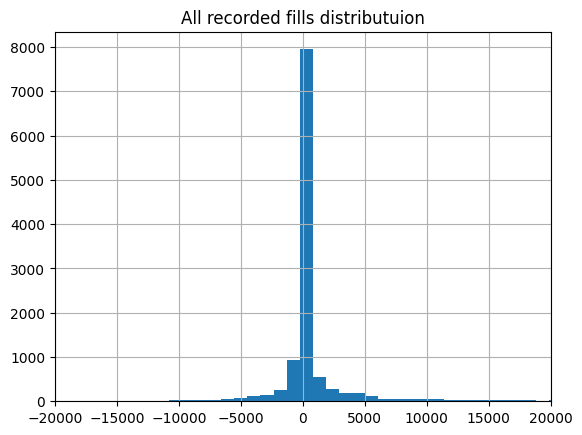

count     11582.000000
mean        458.266966
std        5172.764186
min     -270000.000000
25%         -45.000000
50%          11.000000
75%         240.000000
max      153143.000000
Name: volume, dtype: float64

In [267]:
from matplotlib import pyplot as plt 
hist_df = orders_df.copy()
hist_df.loc[hist_df['side'] == "SELL", 'volume'] *= -1

plt.hist(hist_df['volume'], bins=400)
plt.xlim(-20000, 20000)
plt.grid()
plt.title("All recorded fills distributuion")
plt.show()

hist_df['volume'].describe()

In [268]:
engine = create_engine(url)

orderbooks_df = pd.read_sql("orderbooks", engine)
orderbooks_df.head(1)

,id,ticker,class_code,timestamp,bids,asks,bid_volume,ask_volume
0,959197,SR320CE6A,OPTSPOT,2026-05-04 15:18:06+00:00,"[{'price': 1.33, 'quantity': 800}, {'price': 1...","[{'price': 1.68, 'quantity': 4000}, {'price': ...",136517,11968


In [269]:
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.sort_index(inplace=True)
orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume
timestamp,,,,,,,
2026-03-23 15:39:07+00:00,32065,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1


In [270]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['mid'] = (orderbooks_df['best_ask'] + orderbooks_df['best_bid'])/2

orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume,best_bid,best_ask,mid
timestamp,,,,,,,,,,
2026-03-23 15:39:07+00:00,32065,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1,NaN,0.54,NaN


In [271]:
large_buy_orders['ts_adj'] = large_buy_orders.index + pd.Timedelta(microseconds=1)
df = pd.merge_asof(
    large_buy_orders.reset_index().sort_values('ts_adj'), 
    orderbooks_df[['ticker', 'best_bid', 'best_ask', 'mid']].reset_index(),
    left_on='ts_adj', 
    right_on = 'timestamp',
    by='ticker',
    direction='forward')

df.sort_values("volume", ascending=False).head()

,timestamp_x,id,ticker,class_code,side,volume,price,quantity,strike,ts_adj,timestamp_y,best_bid,best_ask,mid
40,2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310,2026-04-01 10:56:46.000001+00:00,2026-04-01 10:58:55+00:00,8.19,8.50,8.345
196,2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340,2026-05-06 13:48:07.000001+00:00,2026-05-06 13:48:12+00:00,16.25,17.99,17.120
4,2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310,2026-03-25 11:46:13.000001+00:00,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
0,2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310,2026-03-25 06:19:33.000001+00:00,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
164,2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320,2026-04-24 19:06:47.000001+00:00,2026-04-24 19:06:48+00:00,8.20,8.78,8.490


In [272]:
df = df[['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'timestamp_y', 'best_bid', 'best_ask', 'mid']]
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
1,2026-03-25 07:52:50+00:00,SR340CP6A,16672,20,340,2026-03-25 07:52:51+00:00,20.38,20.84,20.610
2,2026-03-25 08:53:17+00:00,SR340CP6A,16736,20,340,2026-03-25 08:53:18+00:00,20.38,21.09,20.735
3,2026-03-25 10:20:40+00:00,SR340CP6B,16320,20,340,2026-03-25 10:23:10+00:00,19.70,20.87,20.285
4,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340


In [310]:
horizons = [5, 30, 60, 120, 480, 720, 1440, 4320, 10080] #minues
horizons = np.linspace(1, 10080, 20, dtype=int)
print(horizons)
for h in horizons:
    df['time_adj'] = df['timestamp_y'] + pd.Timedelta(minutes=h)
    merged = pd.merge_asof(
        df.sort_values('time_adj'),
        orderbooks_df.reset_index(),
        left_on = 'time_adj',
        right_on = 'timestamp',
        direction = 'nearest',
        tolerance = pd.Timedelta(minutes = h/2),
        by = 'ticker'
    ).sort_index() 
    df[f'best_ask_{h}'] = merged['best_ask_y']
    df[f'best_bid_{h}'] = merged['best_bid_y']
    df[f'mid_{h}'] = merged['mid_y']
    
df.head()

[    1   531  1061  1592  2122  2653  3183  3714  4244  4775  5305  5836
  6366  6897  7427  7958  8488  9019  9549 10080]


C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\1415032118.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'mid_{h}'] = merged['mid_y']
C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\1415032118.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'best_ask_{h}'] = merged['best_ask_y']
C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\1415032118.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid,time_adj,...,mid_7958,best_ask_8488,best_bid_8488,mid_8488,best_ask_9019,best_bid_9019,mid_9019,best_ask_9549,best_bid_9549,mid_9549
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810,2026-04-01 06:19:34+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-25 07:52:50+00:00,SR340CP6A,16672,20,340,2026-03-25 07:52:51+00:00,20.38,20.84,20.610,2026-04-01 07:52:51+00:00,...,25.37,25.20,24.86,25.030,26.34,26.00,26.170,NaN,18.22,NaN
2,2026-03-25 08:53:17+00:00,SR340CP6A,16736,20,340,2026-03-25 08:53:18+00:00,20.38,21.09,20.735,2026-04-01 08:53:18+00:00,...,NaN,25.33,24.99,25.160,26.49,26.15,26.320,NaN,18.22,NaN
3,2026-03-25 10:20:40+00:00,SR340CP6B,16320,20,340,2026-03-25 10:23:10+00:00,19.70,20.87,20.285,2026-04-01 10:23:10+00:00,...,24.27,25.10,24.93,25.015,24.97,24.80,24.885,24.37,24.20,24.285
4,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340,2026-04-01 11:46:14+00:00,...,8.88,8.36,7.88,8.120,8.69,7.12,7.905,NaN,7.50,NaN


In [311]:
for h in horizons:
    df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']

C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\1456302144.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']


In [312]:
filtered_df = df.loc[df['strike'].astype(int) > 340]

snr_not_filtered = []
snr_filtered = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    filtered_returns = df.loc[df['strike'].astype(int) > 330][f'mid_price_return_{h}'].dropna()

    print(f"h = {h}, count = {len(returns)}")
    mean = returns.mean()
    std = returns.std()
    snr_not_filtered.append(mean/std)

    mean = filtered_returns.mean()
    std = filtered_returns.std()
    snr_filtered.append(mean/std)

h = 1, count = 94
h = 531, count = 151
h = 1061, count = 110
h = 1592, count = 152
h = 2122, count = 94
h = 2653, count = 103
h = 3183, count = 140
h = 3714, count = 81
h = 4244, count = 112
h = 4775, count = 100
h = 5305, count = 89
h = 5836, count = 125
h = 6366, count = 87
h = 6897, count = 91
h = 7427, count = 113
h = 7958, count = 86
h = 8488, count = 109
h = 9019, count = 121
h = 9549, count = 69
h = 10080, count = 149


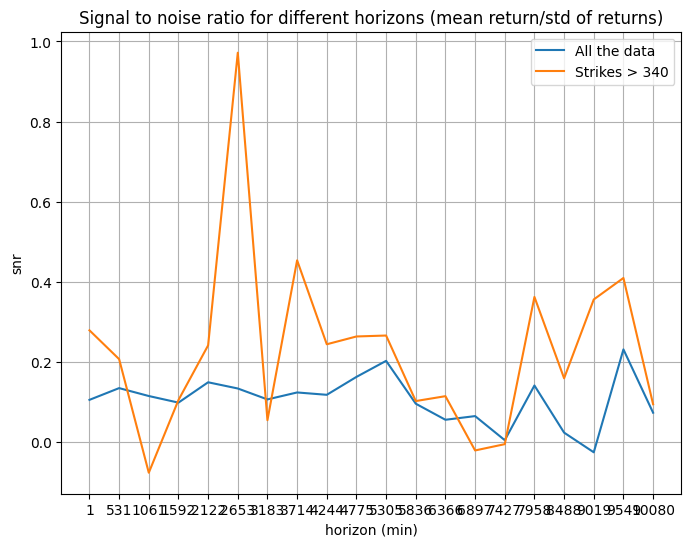

In [313]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), snr_not_filtered, label="All the data")
plt.plot(range(len(horizons)), snr_filtered, label="Strikes > 340")
plt.xticks(range(len(horizons)), horizons)
plt.grid()
plt.title("Signal to noise ratio for different horizons (mean return/std of returns)")
plt.xlabel("horizon (min)")
plt.ylabel("snr")
plt.legend()
plt.show()

In [314]:
stats = pd.DataFrame({
    'mean': [df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std': [df[f'mid_price_return_{h}'].std() for h in horizons],
    'count': [df[f'mid_price_return_{h}'].notna().sum() for h in horizons],
    'mean_otm': [filtered_df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std_otm': [filtered_df[f'mid_price_return_{h}'].std() for h in horizons],
    'count_otm': [filtered_df[f'mid_price_return_{h}'].notna().sum() for h in horizons]
}, index=horizons)
stats

,mean,std,count,mean_otm,std_otm,count_otm
1,0.055483,0.526983,94,0.004836,0.006456,7
531,0.343641,2.553115,151,0.014679,0.034365,7
1061,0.309905,2.698126,110,0.028561,0.034236,3
1592,0.220361,2.240004,152,0.032771,0.079207,2
2122,0.190330,1.276201,94,NaN,NaN,0
2653,0.387792,2.901320,103,NaN,NaN,0
3183,0.268067,2.519767,140,NaN,NaN,0
3714,0.102742,0.830212,81,NaN,NaN,0
4244,0.322850,2.738827,112,NaN,NaN,0
4775,0.472818,2.908154,100,0.137472,NaN,1


In [315]:
from scipy import stats

rows = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    t_stat, p_value = stats.ttest_1samp(returns, popmean=0)

    rows.append({
        'horizon': h,
        't_stat': t_stat,
        'p_value': p_value
    })

t_test_res = pd.DataFrame(rows)
t_test_res

,horizon,t_stat,p_value
0,1,1.020771,0.310011
1,531,1.653951,0.100229
2,1061,1.204655,0.230946
3,1592,1.212852,0.227081
4,2122,1.445949,0.151553
5,2653,1.356506,0.177933
6,3183,1.258770,0.210224
7,3714,1.113781,0.268708
8,4244,1.247513,0.214835
9,4775,1.625835,0.107164


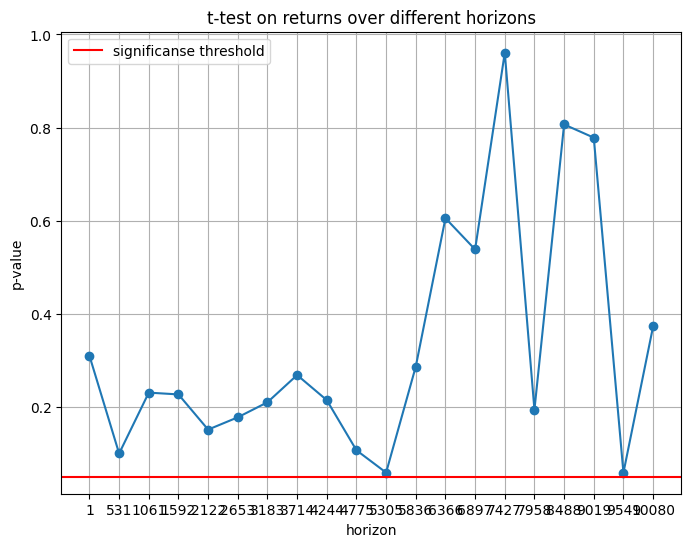

In [316]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), t_test_res['p_value'], marker="o")
plt.xticks(range(len(horizons)), horizons)
plt.xticks()
plt.grid()
plt.xlabel("horizon")
plt.ylabel("p-value")
plt.axhline(0.05, color='red', label="significanse threshold")
plt.title("t-test on returns over different horizons")
plt.legend()
plt.show()

In [317]:
df.columns[0:20]

cols = ['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'best_ask'] + [f'best_bid_{h}' for h in horizons] 
backtest_df = df[cols]

for h in horizons:
    ask = backtest_df[f'best_ask']
    bid = backtest_df[f'best_bid_{h}']
    backtest_df[f'bid_ask_return_{h}'] = (bid - ask)/ask
backtest_df.head(1)

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_1,best_bid_531,best_bid_1061,best_bid_1592,...,bid_ask_return_5305,bid_ask_return_5836,bid_ask_return_6366,bid_ask_return_6897,bid_ask_return_7427,bid_ask_return_7958,bid_ask_return_8488,bid_ask_return_9019,bid_ask_return_9549,bid_ask_return_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,9.31,8.31,6.85,6.63,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [318]:
for h in horizons:
    backtest_df[f'equity_{h}'] = backtest_df[f'bid_ask_return_{h}'].cumsum()
backtest_df

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_1,best_bid_531,best_bid_1061,best_bid_1592,...,equity_5305,equity_5836,equity_6366,equity_6897,equity_7427,equity_7958,equity_8488,equity_9019,equity_9549,equity_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,9.31,8.31,6.85,6.63,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-25 07:52:50+00:00,SR340CP6A,16672,20,340,20.84,NaN,20.97,0.02,22.21,...,0.172745,0.100768,0.100768,0.100768,0.169386,0.209213,0.192898,0.247601,-0.125720,0.102687
2,2026-03-25 08:53:17+00:00,SR340CP6A,16736,20,340,21.09,NaN,20.97,0.02,22.12,...,0.331588,0.188487,0.188487,0.188487,0.307366,0.017179,0.377820,0.487525,-0.261803,0.191829
3,2026-03-25 10:20:40+00:00,SR340CP6B,16320,20,340,20.87,NaN,19.88,0.02,21.84,...,0.358900,0.215799,0.215799,0.215799,0.492320,0.171947,0.572358,0.675833,-0.102244,0.237828
4,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,12.68,NaN,11.60,10.88,10.70,...,-0.036999,-0.180100,-0.180100,-0.143034,0.137431,-0.182943,0.193809,0.237348,-0.510761,-0.045295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2026-05-06 13:48:07+00:00,SR340CR6,17990,17,340,17.99,NaN,0.02,16.64,16.83,...,-71.750236,-28.217066,-67.945194,-61.184311,-44.308645,-68.587339,-51.167571,-40.452246,NaN,NaN
196,2026-05-06 13:48:07+00:00,SR340CR6,89950,17,340,17.99,NaN,0.02,16.64,16.83,...,-72.749125,-29.215954,-68.944082,-62.183200,-45.307533,-69.586227,-52.166460,-41.451134,NaN,NaN
197,2026-05-07 14:42:08+00:00,SR320CQ6,20405,3,320,3.71,NaN,3.00,2.42,3.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
198,2026-05-07 18:16:10+00:00,SR310CQ6B,18480,0,310,0.49,NaN,0.05,0.15,0.05,...,-73.647084,-30.113914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0, 0.5, 'Equity')

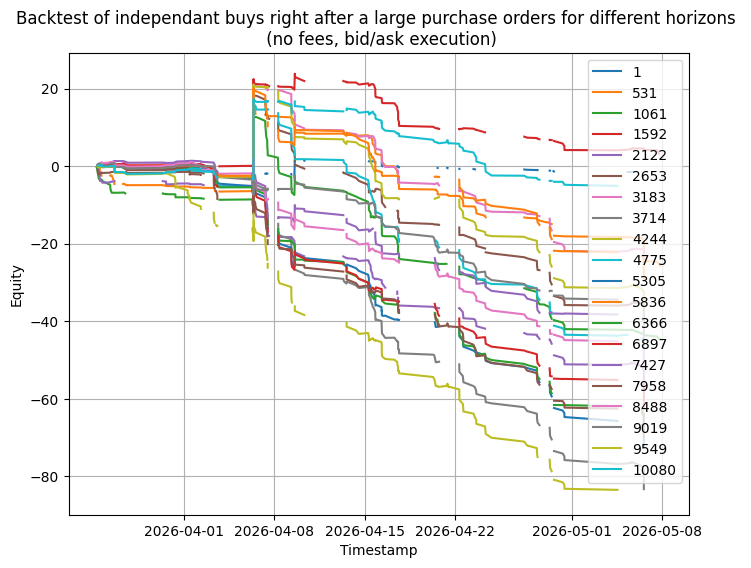

In [319]:
fig = plt.figure(figsize=(8,6))
for h in horizons:
    plt.plot(backtest_df['timestamp_x'], backtest_df[f'equity_{h}'], label=f"{h}")
plt.grid()
plt.legend()
plt.title("Backtest of independant buys right after a large purchase orders for different horizons \n (no fees, bid/ask execution)")
plt.xlabel("Timestamp")
plt.ylabel("Equity")

[np.float64(-0.07670454545454553), np.float64(-0.1445086705202312), np.float64(-0.04142581888246642), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.8979591836734694), np.float64(-0.9988882712618121), np.float64(-0.9988882712618121), np.float64(-0.9988882712618121), np.float64(-0.9988882712618121), np.float64(-0.9988882712618121), np.float64(-0.9988882712618121), np.float64(-0.9989594172736733), np.float64(-0.271461716937355)]


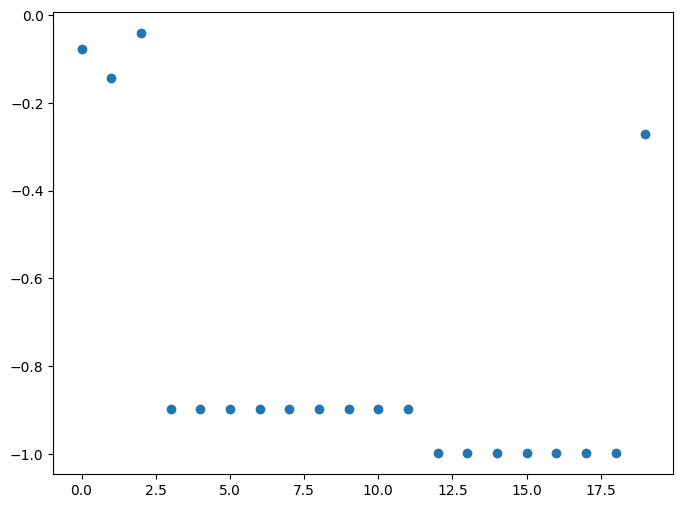

In [328]:
total_returns = []
for h in horizons:
    total_return = backtest_df.dropna(subset=[f'bid_ask_return_{h}']).iloc[-1][f'bid_ask_return_{h}']
    total_returns.append(total_return)

print(total_returns)
fig = plt.figure(figsize = (8, 6))
plt.scatter(range(len(horizons)), total_returns)